In [11]:
! pip install tensorflow matplotlib scikit-learn pandas

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Makes random initialization and data splitting more reproducible
SEED = 42
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
Available GPUs: []


In [13]:
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Training images:", x_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)
print("Image data type:", x_train_full.dtype)
print("Pixel range:", x_train_full.min(), "to", x_train_full.max())

# Verify dataset structure
assert x_train_full.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)
assert set(np.unique(y_train_full)) == set(range(10))

print("\nDataset checks passed.")

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)
Image data type: uint8
Pixel range: 0 to 255

Dataset checks passed.


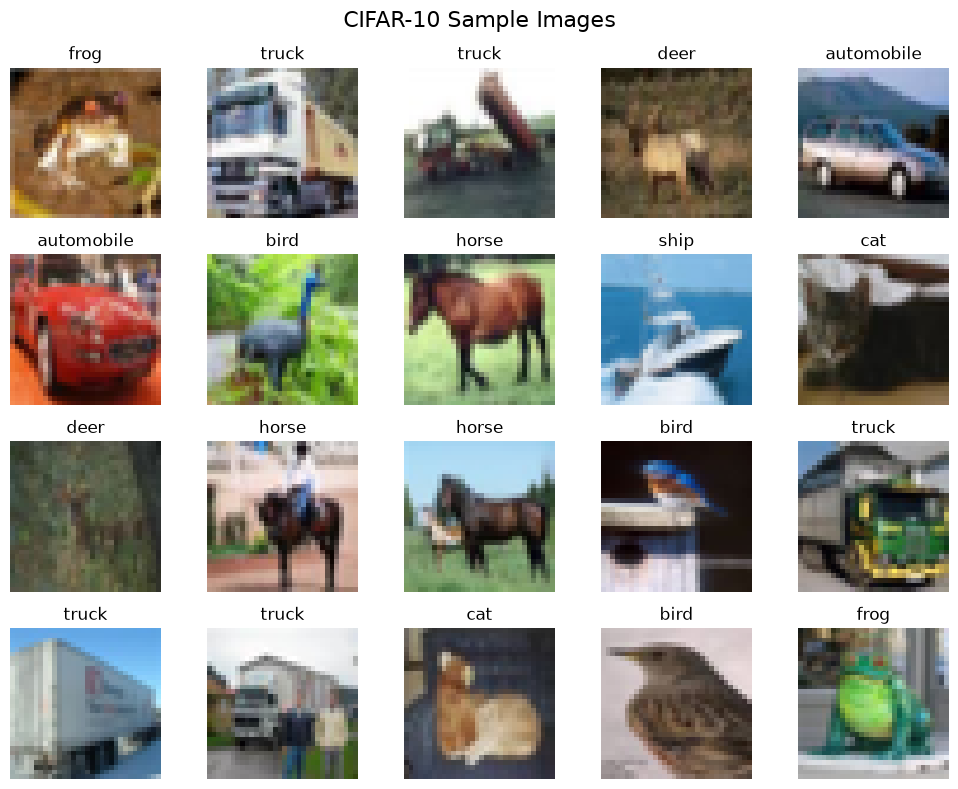

In [14]:

plt.figure(figsize=(10, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train_full[i])
    label = int(y_train_full[i, 0])
    plt.title(class_names[label])
    plt.axis("off")

plt.suptitle("CIFAR-10 Sample Images", fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
# Convert label arrays from (N, 1) to (N,)
y_train_full = y_train_full.reshape(-1)
y_test = y_test.reshape(-1)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train_full
)

# Release the original training array to reduce memory usage
del x_train_full, y_train_full

print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)

assert len(x_train) == 45000
assert len(x_val) == 5000
assert len(x_test) == 10000

Training set: (45000, 32, 32, 3) (45000,)
Validation set: (5000, 32, 32, 3) (5000,)
Test set: (10000, 32, 32, 3) (10000,)


In [16]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Normalize pixels from [0, 255] to [0, 1]
    layers.Rescaling(1.0 / 255),

    # First convolution block
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Third convolution block
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.40),
    layers.Dense(10, activation="softmax")
], name="CIFAR10_CNN")

model.summary()

assert model.output_shape == (None, 10)
print("\nOutput shape check passed:", model.output_shape)

Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,986 (1.54 MB)

 Trainable params: 402,986 (1.54 MB)

 Non-trainable params: 0 (0.00 B)


Output shape check passed: (None, 10)


In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [18]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks configured.")

Callbacks configured.


In [19]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.3652 - loss: 1.7084 - val_accuracy: 0.5026 - val_loss: 1.3569 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.5269 - loss: 1.3117 - val_accuracy: 0.6064 - val_loss: 1.1022 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.5989 - loss: 1.1235 - val_accuracy: 0.6726 - val_loss: 0.9067 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.6442 - loss: 1.0094 - val_accuracy: 0.6934 - val_loss: 0.8484 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.6750 - loss: 0.9276 - val_accuracy: 0.7054 - val_loss: 0.8122 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.6923 - loss: 0.8751 - val_accuracy: 0.7274 - val_loss: 0.7575 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.7119 - l

In [20]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    batch_size=128,
    verbose=1
)

print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8160 - loss: 0.5517

Test loss: 0.5517
Test accuracy: 81.60%


In [21]:
probabilities = model.predict(
    x_test,
    batch_size=128,
    verbose=1
)

# Select the class with the highest probability
y_pred = np.argmax(probabilities, axis=1)
confidence = np.max(probabilities, axis=1)

# Check shape, values, and probability sums
assert probabilities.shape == (10000, 10)
assert y_pred.shape == (10000,)
assert np.isfinite(probabilities).all()
assert np.all((probabilities >= 0) & (probabilities <= 1))
assert np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-5)

# Independently confirm reported accuracy
checked_accuracy = accuracy_score(y_test, y_pred)
assert np.isclose(test_accuracy, checked_accuracy, atol=1e-6)

correct_count = np.sum(y_test == y_pred)

print("\nPrediction checks passed.")
print("Probability array shape:", probabilities.shape)
print("Prediction array shape:", y_pred.shape)
print(f"Correct predictions: {correct_count} / {len(y_test)}")
print(f"Incorrect predictions: {len(y_test) - correct_count}")
print(f"Verified test accuracy: {checked_accuracy:.2%}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step

Prediction checks passed.
Probability array shape: (10000, 10)
Prediction array shape: (10000,)
Correct predictions: 8160 / 10000
Incorrect predictions: 1840
Verified test accuracy: 81.60%


In [22]:
print(
    classification_report(
        y_test,
        y_pred,
        labels=np.arange(10),
        target_names=class_names,
        digits=3,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    airplane      0.808     0.840     0.824      1000
  automobile      0.911     0.912     0.912      1000
        bird      0.749     0.728     0.738      1000
         cat      0.678     0.666     0.672      1000
        deer      0.797     0.798     0.798      1000
         dog      0.749     0.720     0.734      1000
        frog      0.817     0.889     0.852      1000
       horse      0.859     0.829     0.844      1000
        ship      0.898     0.898     0.898      1000
       truck      0.889     0.880     0.884      1000

    accuracy                          0.816     10000
   macro avg      0.816     0.816     0.816     10000
weighted avg      0.816     0.816     0.816     10000



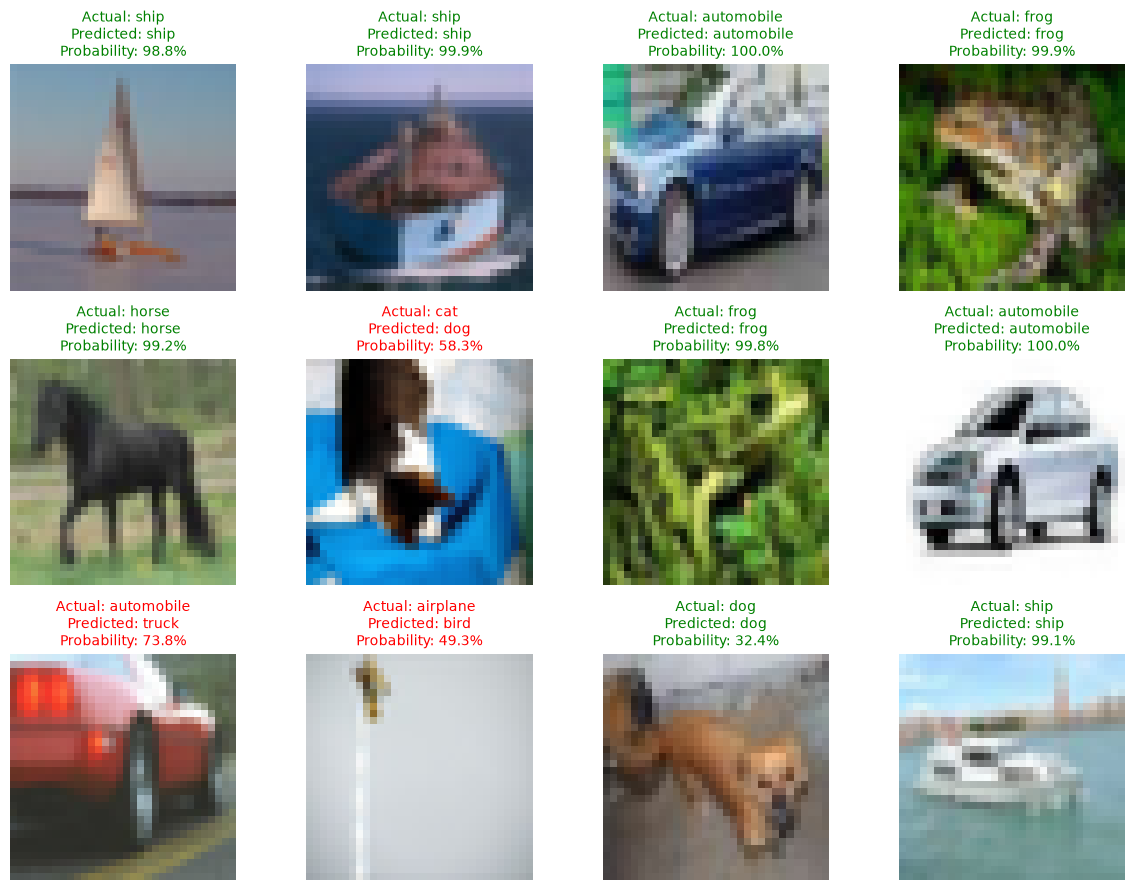

In [23]:
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Select 12 random test images
indices = np.random.default_rng(42).choice(
    len(x_test), size=12, replace=False
)

# Uses the model from the previous code, which normalizes internally
probabilities = model.predict(x_test[indices], verbose=0)
predicted_labels = np.argmax(probabilities, axis=1)
actual_labels = np.asarray(y_test).reshape(-1)[indices]

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, index, actual, predicted, probs in zip(
    axes.flat, indices, actual_labels, predicted_labels, probabilities
):
    ax.imshow(x_test[index])
    ax.set_title(
        f"Actual: {class_names[int(actual)]}\n"
        f"Predicted: {class_names[int(predicted)]}\n"
        f"Probability: {probs[predicted]:.1%}",
        color="green" if actual == predicted else "red",
        fontsize=10
    )
    ax.axis("off")

plt.tight_layout()
plt.show()